## Import packages

In [35]:
import pandas as pd
from statsforecast import StatsForecast 
from statsforecast.models import AutoARIMA
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp
from hierarchicalforecast.utils import aggregate 
from pathlib import Path 
import matplotlib.pyplot as plt

## Load and Prepare Data 

In [36]:
# Load Dataset
df = pd.read_csv(
    r'S:\WP Personnel\A - Workforce\Data science student\Desys Corner\NHS_Leavers_Detail_New.csv',
    parse_dates=['Termination Date'],
    dayfirst=True,
    low_memory=False
)
# Drop rows with missing dates
df = df.dropna(subset=["Termination Date"])

# Create timestamp 'ds' (period start of month) and unique_id
df['ds'] = df['Termination Date'].dt.to_period('M').dt.to_timestamp()
df['unique_id'] = (
    df['Organisation'].str.replace(r'\s+', '', regex=True) + '_' +
    df['Service group'].str.replace(r'\s+', '', regex=True) + '_' +
    df['Staff Group'].str.replace(r'\s+', '', regex=True)
    
)
# 4. Aggregate to monthly counts
monthly = (
    df
    .groupby(['unique_id', 'ds'])
    .size()
    .reset_index(name='y')
)

## Create hierarchy structure 

In [37]:
monthly['Total'] = 'Total'
monthly[['Org', 'Service', 'Staff']] = monthly['unique_id'].str.split('_', expand=True)

# Clean hierarchy columns 
for col in ['Org', 'Service', 'Staff']:
    monthly[col] = monthly[col].str.replace('/','_')
    monthly[col] = monthly[col].str.replace('&', 'and')

# Remove duplicate columns 
monthly = monthly.loc[:, ~monthly.columns.duplicated()].copy()

## Aggregate hierarchy 

In [43]:
Y_df, S_df, tags = aggregate(
    df=monthly, 
    spec=[
        ['Total'],
        ['Total', 'Org'],
        ['Total', 'Org', 'Service'],
        ['Total', 'Org', 'Service', 'Staff']
    ],
    id_col='unique_id',
    time_col='ds',
    target_cols=('y',)
)

## Fit ARIMA and Forecast 

In [42]:
sf = StatsForecast(models=[AutoARIMA(season_length=12)], freq='MS', n_jobs=-1) 
sf.fit(Y_df)
Y_hat = sf.predict(h=12, level=[80, 95])

## Hierarchial Reconciliation 

In [44]:
hrec = HierarchicalReconciliation(reconcilers=[BottomUp()])
Y_rec = hrec.reconcile(Y_hat_df=Y_hat, Y_df=Y_df, S=S_df, tags=tags)

## Save Forecasts

In [27]:
out_path = Path(r'S:\WP Personnel\A - Workforce\Data science student\Desys Corner\hierarchical_forecast_output.csv')
Y_rec.to_csv(out_path, index=False)
print(f"Forecast saved to {out_path}")

Forecast saved to S:\WP Personnel\A - Workforce\Data science student\Desys Corner\hierarchical_forecast_output.csv


## Plot One Forecast 

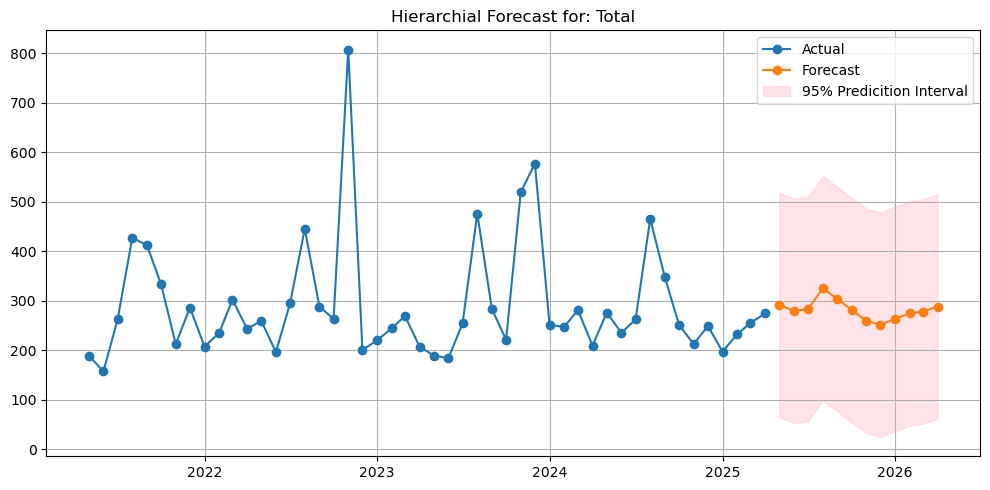

In [46]:
sample_uid = Y_rec['unique_id'].iloc[0]
act = Y_df[Y_df['unique_id'] == sample_uid]
fc = Y_rec[Y_rec['unique_id'] == sample_uid]

plt.figure(figsize=(10, 5))
plt.plot(act['ds'], act['y'], label='Actual', marker='o') # Actuals
plt.plot(fc['ds'], fc['AutoARIMA'], label='Forecast', marker='o') #point
plt.fill_between(
    fc['ds'],
    fc['AutoARIMA-lo-95'],
    fc['AutoARIMA-hi-95'],
    color='pink',
    alpha=0.4,
    label='95% Predicition Interval'
)

plt.title(f"Hierarchial Forecast for: {sample_uid}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
# This doesnt take into account current politics and trends within the NHS